# Úkol 4


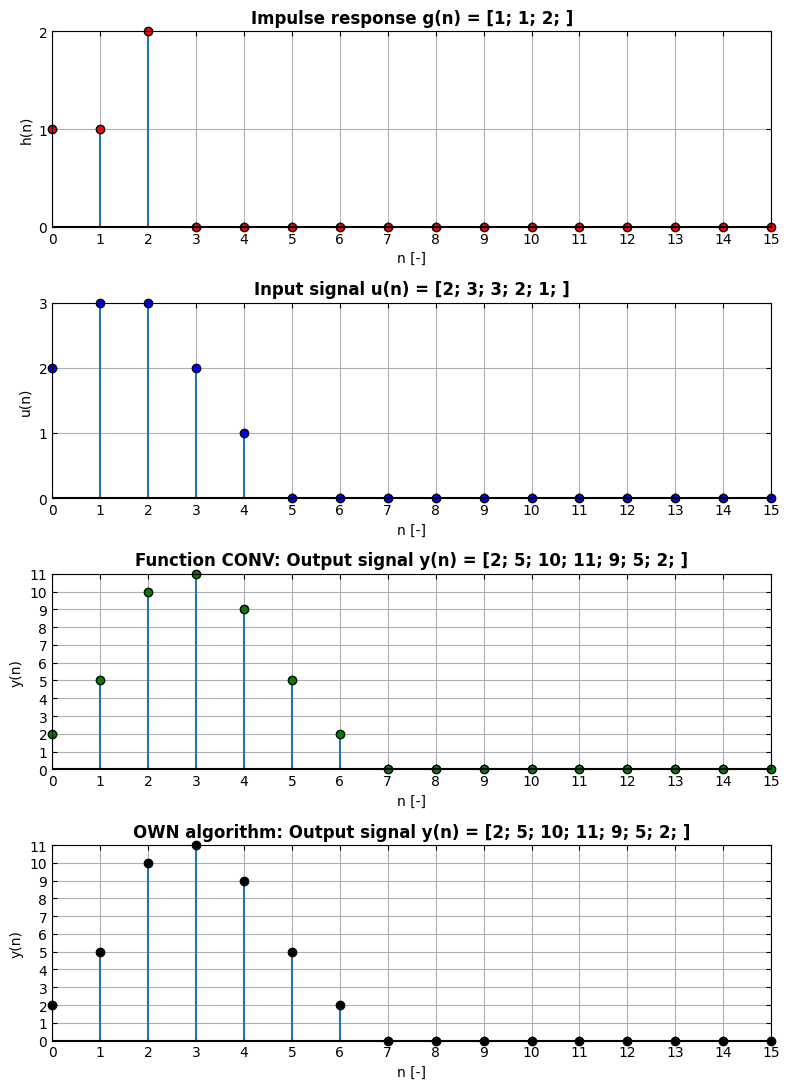

In [1]:
import numpy as np
import matplotlib.pyplot as plt

u = np.array([2, 3, 3, 2, 1])
g = np.array([1, 1, 2])

N = len(u)
M = len(g)
D = N + M - 1

y_own = np.zeros(D)
for i in range(D):
    for k in range(M):
        if 0 <= i - k < N:
            y_own[i] += u[i - k] * g[k]

y_conv = np.convolve(u, g)

n_axis = np.arange(16)
u_plot = np.pad(u, (0, 16 - N))
g_plot = np.pad(g, (0, 16 - M))
y_conv_plot = np.pad(y_conv, (0, 16 - D))
y_own_plot = np.pad(y_own, (0, 16 - D))

fig, axs = plt.subplots(4, 1, figsize=(8, 11))

markerline, stemlines, baseline = axs[0].stem(n_axis, g_plot, linefmt='C0-', markerfmt='ro', basefmt='k-')
axs[0].set_title('Impulse response g(n) = [1; 1; 2; ]', fontweight='bold')
axs[0].set_ylabel('h(n)')
axs[0].set_xlabel('n [-]')
axs[0].set_xticks(n_axis)
axs[0].set_xlim(0, 15)
axs[0].set_yticks(np.arange(0, 3))
axs[0].set_ylim(0, 2)
axs[0].tick_params(direction='in', top=True, right=True)
axs[0].grid(True)
plt.setp(markerline, markeredgecolor='k', clip_on=False)

markerline, stemlines, baseline = axs[1].stem(n_axis, u_plot, linefmt='C0-', markerfmt='bo', basefmt='k-')
axs[1].set_title('Input signal u(n) = [2; 3; 3; 2; 1; ]', fontweight='bold')
axs[1].set_ylabel('u(n)')
axs[1].set_xlabel('n [-]')
axs[1].set_xticks(n_axis)
axs[1].set_xlim(0, 15)
axs[1].set_yticks(np.arange(0, 4))
axs[1].set_ylim(0, 3)
axs[1].tick_params(direction='in', top=True, right=True)
axs[1].grid(True)
plt.setp(markerline, markeredgecolor='k', clip_on=False)

markerline, stemlines, baseline = axs[2].stem(n_axis, y_conv_plot, linefmt='C0-', markerfmt='go', basefmt='k-')
axs[2].set_title('Function CONV: Output signal y(n) = [2; 5; 10; 11; 9; 5; 2; ]', fontweight='bold')
axs[2].set_ylabel('y(n)')
axs[2].set_xlabel('n [-]')
axs[2].set_xticks(n_axis)
axs[2].set_xlim(0, 15)
axs[2].set_yticks(np.arange(0, 12))
axs[2].set_ylim(0, 11)
axs[2].tick_params(direction='in', top=True, right=True)
axs[2].grid(True)
plt.setp(markerline, markeredgecolor='k', clip_on=False)

markerline, stemlines, baseline = axs[3].stem(n_axis, y_own_plot, linefmt='C0-', markerfmt='ko', basefmt='k-')
axs[3].set_title('OWN algorithm: Output signal y(n) = [2; 5; 10; 11; 9; 5; 2; ]', fontweight='bold')
axs[3].set_ylabel('y(n)')
axs[3].set_xlabel('n [-]')
axs[3].set_xticks(n_axis)
axs[3].set_xlim(0, 15)
axs[3].set_yticks(np.arange(0, 12))
axs[3].set_ylim(0, 11)
axs[3].tick_params(direction='in', top=True, right=True)
axs[3].grid(True)
plt.setp(markerline, markeredgecolor='k', clip_on=False)

plt.tight_layout()
plt.show()


## Komentář

Nejprve jsem importoval nezbytné knihovny. Následně jsem definoval zadané proměnné: vstupní posloupnost u(n) = [2, 3, 3, 2, 1] a impulsní odezvu g(n) = [1, 1, 2]. Z těchto hodnot jsem odvodil délku vstupního signálu $N$ a délku konvolučního jádra $M$, abych mohl určit celkovou délku výstupní posloupnosti $D$ podle vztahu $D = N + M - 1$.

Vlastní konvoluci jsem naprogramoval pomocí vnořených cyklů přesně podle zadané definiční rovnice pro konvolutorní sumu. Algoritmus postupně posouvá impulsní odezvu vůči vstupnímu signálu a akumuluje součiny překrývajících se vzorků do předpřipraveného pole nul o odpovídající délce. Pro srovnávací účely jsem zároveň vypočítal odezvu systému pomocí vestavěné funkce `numpy.convolve`.

Pro názornou vizualizaci jsem vygeneroval čtyři grafy pod sebou. První graf přehledně zobrazuje zadanou impulsní odezvu a druhý vstupní signál. Třetí a čtvrtý graf pak prezentují výsledné výstupní signály z vestavěné funkce a z mého vlastního algoritmu. Vizuálním porovnáním třetího a čtvrtého grafu, jsem potvrdil, že obě metody poskytly zcela identickou výstupní posloupnost y(n) = [2, 5, 10, 11, 9, 5, 2].
